In [1]:
import os
os.environ.setdefault("PYTENSOR_FLAGS", "cxx=")
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


In [2]:
sns.set_theme(style="whitegrid")

In [3]:
tips = pd.read_csv("../data/own_robust_data.csv")


In [4]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,40.05,4.19,Male,No,Sun,Dinner,4
1,25.31,4.48,Female,No,Sat,Dinner,4
2,43.78,3.76,Male,Yes,Sun,Lunch,4
3,36.68,4.37,Female,No,Sat,Dinner,1
4,10.14,2.08,Female,Yes,Fri,Dinner,5


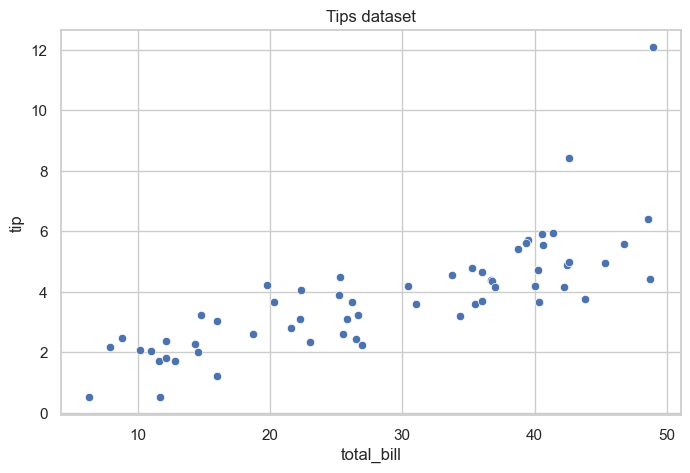

In [5]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip"
)

plt.title("Tips dataset");

In [6]:
x = tips["total_bill"].values
y = tips["tip"].values

In [7]:
x_mean = x.mean()
x_std = x.std()

x_scaled = (x - x_mean) / x_std

In [8]:
with pm.Model() as robust_model:

    alpha = pm.Normal("alpha", mu=0, sigma=10)

    beta = pm.Normal("beta", mu=0, sigma=10)

    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * x_scaled

    y_obs = pm.StudentT(
        "y_obs",
        nu=3,
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace_robust = pm.sample(
        draws=200,
        tune=200,
        chains=2,
        cores=1,
        progressbar=False,
        compile_kwargs={"mode": "NUMBA"},
        target_accept=0.98,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta, sigma]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [9]:
az.summary(
    trace_robust,
    var_names=["alpha", "beta", "sigma"]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.685,0.109,3.479,3.870,0.008,0.007,219.0,256.0,1.01
beta,1.209,0.121,0.994,1.427,0.008,0.006,235.0,210.0,1.00
sigma,0.704,0.092,0.552,0.897,0.006,0.006,247.0,108.0,1.01


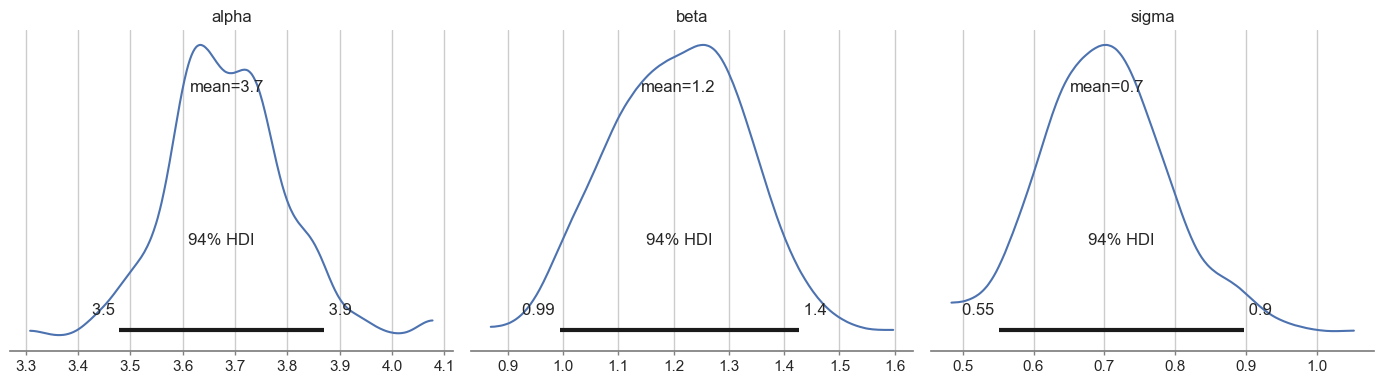

In [10]:
az.plot_posterior(
    trace_robust,
    var_names=["alpha", "beta", "sigma"],
    figsize=(14, 4)
)

plt.tight_layout();

In [11]:
posterior = trace_robust.posterior

alpha_samples = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_samples = posterior["beta"].stack(sample=("chain", "draw")).values

x_grid = np.linspace(x_scaled.min(), x_scaled.max(), 100)

y_lines = alpha_samples[:, None] + beta_samples[:, None] * x_grid[None, :]

y_mean = y_lines.mean(axis=0)
y_hdi = az.hdi(y_lines, hdi_prob=0.94)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13560\3883998849.py:11: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_lines, hdi_prob=0.94)


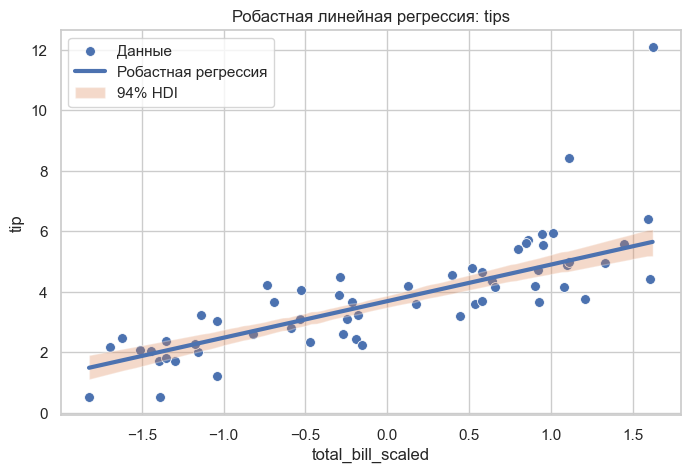

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=x_scaled,
    y=y,
    s=50,
    label="Данные"
)

plt.plot(
    x_grid,
    y_mean,
    linewidth=3,
    label="Робастная регрессия"
)

plt.fill_between(
    x_grid,
    y_hdi[:, 0],
    y_hdi[:, 1],
    alpha=0.3,
    label="94% HDI"
)

plt.xlabel("total_bill_scaled")
plt.ylabel("tip")

plt.title("Робастная линейная регрессия: tips")

plt.legend();

In [13]:
with robust_model:
    ppc = pm.sample_posterior_predictive(
        trace_robust,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

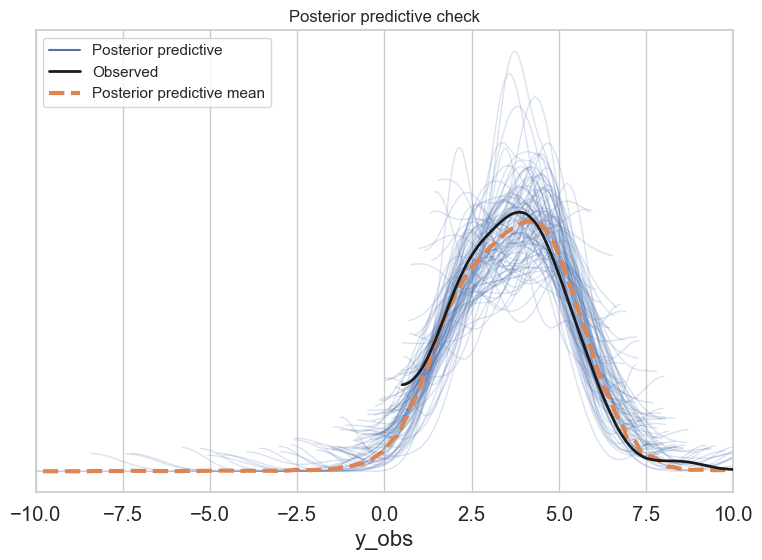

In [14]:
az.plot_ppc(
    ppc,
    num_pp_samples=100,
    figsize=(9, 6)
)

plt.xlim(-10, 10)

plt.title("Posterior predictive check");